In [1]:
import os
import json
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter
from skimage import exposure
from skimage import data, img_as_float
import matplotlib
import numpy as np
matplotlib.rcParams['font.size'] = 8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import skimage 
from skimage.segmentation import clear_border
from skimage.morphology import white_tophat, disk,remove_small_objects
import matplotlib.patches as mpatches
from skimage.transform import resize
from skimage.filters import threshold_otsu

In [2]:
BASE_DIR = Path(r"c:/Users/ANING/Downloads/54816/54816")

DIR_24   = BASE_DIR / "24_chromosomes_object"
DIR_SNGL = BASE_DIR / "single_chromosomes_object"

ANN_24   = DIR_24 / "annotations"
IMG_24   = DIR_24 / "JEPG"        

ANN_SNGL = DIR_SNGL / "anntations" 
IMG_SNGL = DIR_SNGL / "JEPG"

TRAIN_TXT = BASE_DIR / "train.txt"
TEST_TXT  = BASE_DIR / "test.txt"
DIFF_TXT  = BASE_DIR / "diff_image.txt"

In [3]:
import random

all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))
all_img_sngl = sorted(IMG_SNGL.glob("*.jpg")) + sorted(IMG_SNGL.glob("*.JPG"))


SUBSET_SIZE = 100
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24
img_sngl = random.sample(all_img_sngl, min(SUBSET_SIZE, len(all_img_sngl))) if SUBSET_SIZE else all_img_sngl

print(f"24-chr  subset : {len(img_24)}  / {len(all_img_24)}  total")
print(f"Single  subset : {len(img_sngl)} / {len(all_img_sngl)} total")

24-chr  subset : 100  / 10000  total
Single  subset : 100 / 4000 total


In [4]:
img_raw = skimage.io.imread(img_24[23],as_gray=True)

print("Shape :", img_raw.shape)   
print("dtype :", img_raw.dtype)
print("Range :", img_raw.min().round(3), "–", img_raw.max().round(3))

Shape : (709, 938)
dtype : float64
Range : 0.039 – 1.0


In [476]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

def check_channel_alignment(image_path):

    img = io.imread(image_path)

    if img.ndim != 3 or img.shape[2] != 3:
        print("Image is already single-channel (grayscale).")
        return

    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]


    rg_diff = np.mean(np.abs(r - g))
    rb_diff = np.mean(np.abs(r - b))
    gb_diff = np.mean(np.abs(g - b))

    plt.figure(figsize=(8,5))

    plt.hist(r.ravel(), bins=256, alpha=0.5, label="Red")
    # plt.hist(g.ravel(), bins=256, alpha=0.5, label="Green")
    # plt.hist(b.ravel(), bins=256, alpha=0.5, label="Blue")

    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.title("RGB Channel Intensity Distributions")
    plt.legend()

    plt.show()


    rg_corr = np.corrcoef(r.flatten(), g.flatten())[0,1]
    rb_corr = np.corrcoef(r.flatten(), b.flatten())[0,1]
    gb_corr = np.corrcoef(g.flatten(), b.flatten())[0,1]


    if rg_corr > 0.99 and rb_corr > 0.99 and gb_corr > 0.99:
        print("\nConclusion: Channels are nearly identical → image is grayscale stored as RGB.")
    else:
        print("\nConclusion: Channels differ → real color or multi-channel image.")

    # visualize channels
    fig, ax = plt.subplots(1,3, figsize=(12,4))

    ax[0].imshow(r, cmap="gray")
    ax[0].set_title("Red channel")

    ax[1].imshow(g, cmap="gray")
    ax[1].set_title("Green channel")

    ax[2].imshow(b, cmap="gray")
    ax[2].set_title("Blue channel")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

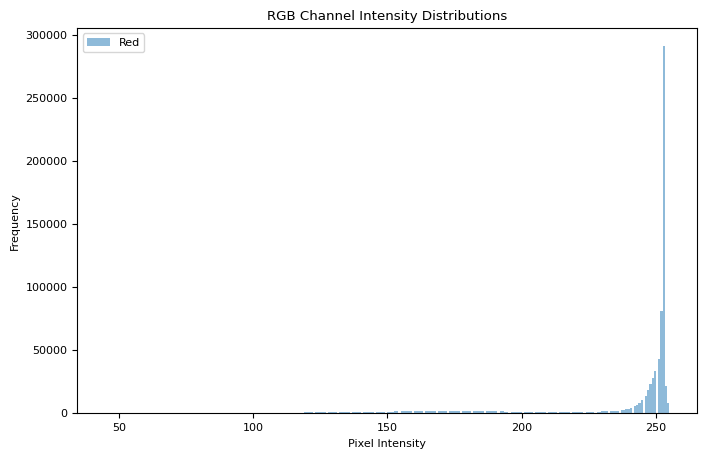


Conclusion: Channels are nearly identical → image is grayscale stored as RGB.


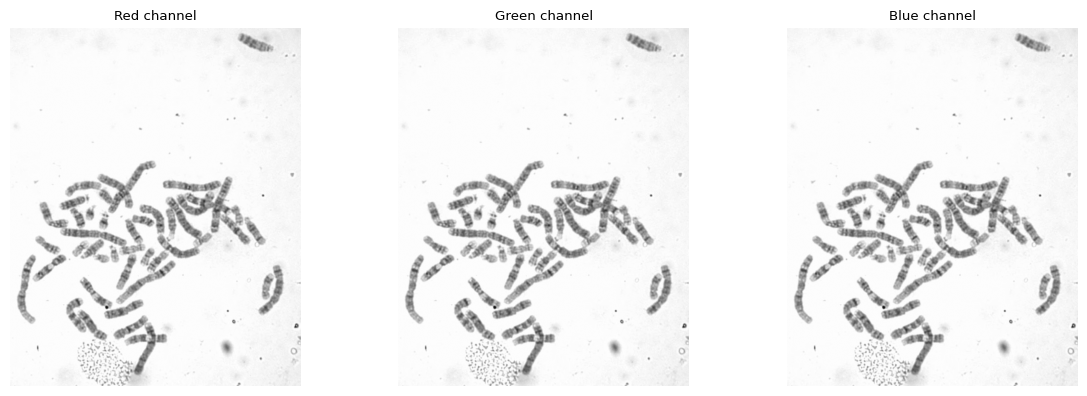

In [477]:
check_channel_alignment(img_24[20])

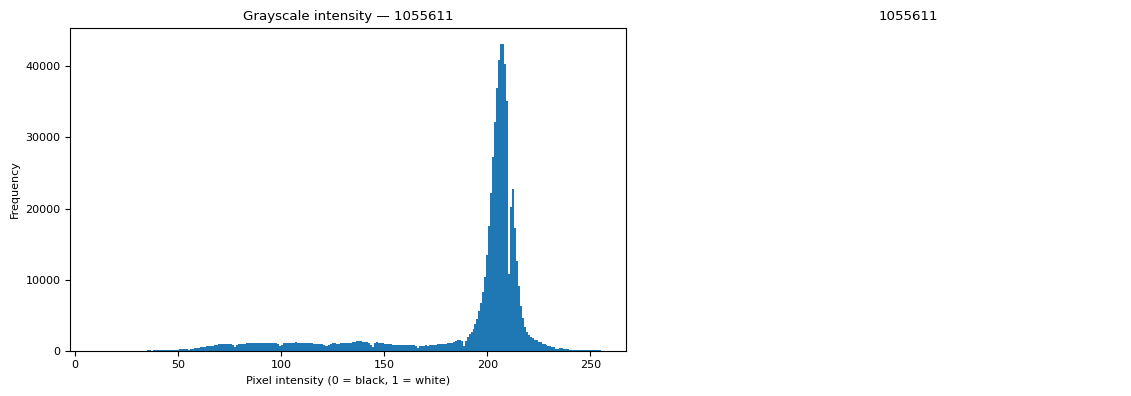

In [7]:
img = skimage.filters.gaussian(img_raw,0.3,preserve_range=True)
img = np.clip(img, 0, 1)
img = img*255
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(img.ravel(), bins=256, )
axes[0].set_title(f"Grayscale intensity — {img_24[0].stem}")
axes[0].set_xlabel("Pixel intensity (0 = black, 1 = white)")
axes[0].set_ylabel("Frequency")


axes[1].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(img_24[0].stem)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [213]:
def plot_img_and_hist(image, axes, bins=256):
    """Plot an image along with its histogram and cumulative histogram."""
    image = img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    # Display image
    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    # Display histogram
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    # Display cumulative distribution
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf


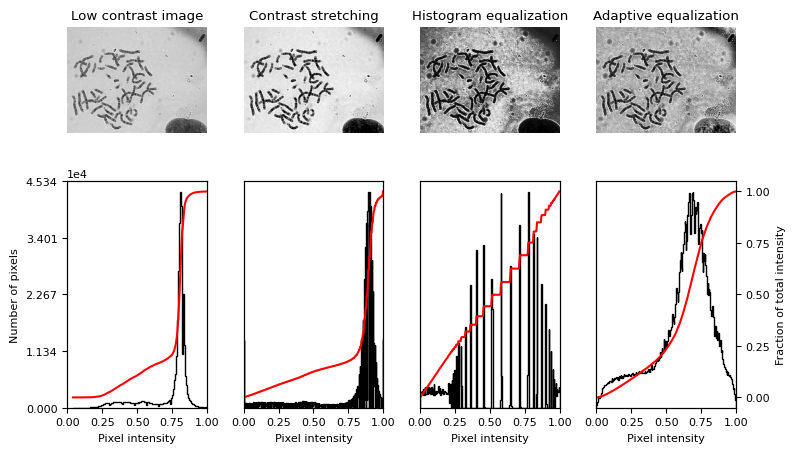

In [214]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Equalization
img_eq = exposure.equalize_hist(img)

# Adaptive Equalization
img_adapteq = exposure.equalize_adapthist(img, clip_limit=0.03)

# Display results
fig = plt.figure(figsize=(8, 5))
axes = np.zeros((2, 4), dtype=object)
axes[0, 0] = fig.add_subplot(2, 4, 1)
for i in range(1, 4):
    axes[0, i] = fig.add_subplot(2, 4, 1 + i, sharex=axes[0, 0], sharey=axes[0, 0])
for i in range(0, 4):
    axes[1, i] = fig.add_subplot(2, 4, 5 + i)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img, axes[:, 0])
ax_img.set_title('Low contrast image')

y_min, y_max = ax_hist.get_ylim()
ax_hist.set_ylabel('Number of pixels')
ax_hist.set_yticks(np.linspace(0, y_max, 5))

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescale, axes[:, 1])
ax_img.set_title('Contrast stretching')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[:, 2])
ax_img.set_title('Histogram equalization')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[:, 3])
ax_img.set_title('Adaptive equalization')

ax_cdf.set_ylabel('Fraction of total intensity')
ax_cdf.set_yticks(np.linspace(0, 1, 5))

# prevent overlap of y-axis labels
fig.tight_layout()
plt.show()

In [449]:
def compute_image_quality_metrics(image_path):

    img = skimage.io.imread(image_path)

    if img.ndim == 3:
        gray = skimage.color.rgb2gray(img)
    else:
        gray = img / 255.0

    metrics = {}

    metrics["contrast"] = np.std(gray)

    laplacian = skimage.filters.laplace(gray)
    metrics["sharpness"] = laplacian.var()

    mean_signal = np.mean(gray)
    noise = np.std(gray)

    metrics["SNR"] = mean_signal / noise if noise != 0 else 0

    block_size = (32,32)

    h, w = gray.shape
    h = h - (h % 32)
    w = w - (w % 32)

    cropped = gray[:h, :w]

    blocks = skimage.util.view_as_blocks(cropped, block_size)

    block_means = blocks.mean(axis=(2,3))
    metrics["background_uniformity"] = np.std(block_means)

    hist, _ = np.histogram(gray, bins=256, range=(0,1))
    metrics["histogram_spread"] = np.std(hist)

    windows = skimage.util.view_as_windows(gray, (15,15))
    local_std_map = np.std(windows, axis=(2,3))

    metrics["local_std_variation"] = np.std(local_std_map)

    return metrics

In [312]:
resized_images = [
    resize(skimage.io.imread(p, as_gray=True), (512,512), 
           preserve_range=True, anti_aliasing=True)
    for p in img_24
]

In [ ]:
def chromosome_mask_with_adaptive_histogram(img_path, 
                        gaussian_sigma=0.3,
                        clahe_clip_limit=0.03,
                        tophat_disk_size=15,
                        block_size=101,
                        opening_disk_size=5,
                        min_object_size=600,
                        plot=True,with_otsu=True):
    """
    Segment chromosomes from a grayscale microscopy image.

    Parameters
    ----------
    img_path        : str or array — file path or preloaded image array
    gaussian_sigma  : float — smoothing strength (default 0.3)
    clahe_clip_limit: float — CLAHE contrast limit (default 0.03)
    tophat_disk_size: int   — structuring element radius for top-hat (default 15)
    block_size      : int   — local threshold window, must be odd (default 101)
    opening_disk_size: int  — morphological opening radius (default 5)
    min_object_size : int   — minimum blob area in pixels to keep (default 600)
    plot            : bool  — show side-by-side figure (default True)

    Returns
    -------
    mask : np.ndarray (bool) — binary chromosome mask
    """

    if isinstance(img_path, (str, Path)):
        img_raw = skimage.io.imread(img_path, as_gray=True)
    else:
        img_raw = img_path.copy()

   
    img = skimage.filters.gaussian(img_raw, gaussian_sigma, preserve_range=True)
    img = np.clip(img, 0, 1)


    img_adapteq = exposure.equalize_adapthist(img, clip_limit=clahe_clip_limit)


    inverted = 1.0 - img_adapteq

    
    tophat = white_tophat(inverted, disk(tophat_disk_size))

    if with_otsu:

        local_thresholds =  threshold_otsu(tophat)

    else:

        local_thresholds = skimage.filters.threshold_local(tophat, block_size, method='gaussian')


    binary_local = tophat > local_thresholds


    binary_opened = skimage.morphology.opening(binary_local, disk(opening_disk_size))
    mask = remove_small_objects(binary_opened,max_size= min_object_size)
    mask = clear_border(mask)


    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title("Preprocessed")
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("Binary mask")
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return mask

In [ ]:
def chromosome_mask_with_contrast_stretching(img_path,
                            gaussian_sigma=0.3,
                            tophat_disk_size=15,
                            block_size=101,
                            opening_disk_size=5,
                            min_object_size=600,
                            plot=True,with_otsu=False):
    """
    Segment chromosomes from a grayscale microscopy image.

    Parameters
    ----------
    img_path          : str, Path, or array — file path or preloaded image array
    gaussian_sigma    : float — smoothing strength (default 0.77)
    tophat_disk_size  : int   — structuring element radius for top-hat (default 30)
    block_size        : int   — local threshold window, must be odd (default 73)
    opening_disk_size : int   — morphological opening radius (default 30)
    min_object_size   : int   — minimum blob area in pixels to keep (default 500)
    plot              : bool  — show side-by-side figure (default True)

    Returns
    -------
    mask : np.ndarray (bool) — binary chromosome mask
    """

    if isinstance(img_path, (str, Path)):
        img_raw = skimage.io.imread(img_path, as_gray=True)
    else:
        img_raw = img_path.copy()

    img = skimage.filters.gaussian(img_raw, gaussian_sigma, preserve_range=True)
    img = np.clip(img, 0, 1)

   
    img_rescale = exposure.rescale_intensity(img)

   
    inverted = 1.0 - img_rescale

   
    tophat = white_tophat(inverted, disk(tophat_disk_size))

    if with_otsu:

        local_thresholds =  threshold_otsu(tophat)

    else:

        local_thresholds = skimage.filters.threshold_local(tophat, block_size, method='gaussian')

    
    binary_opened = skimage.morphology.opening(inverted, disk(opening_disk_size))
    
    mask = binary_opened > local_thresholds

  
    mask = remove_small_objects(mask, max_size=min_object_size)
    mask = clear_border(mask)

   
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title("Preprocessed")
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title("Binary mask")
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return mask

In [484]:
skimage.segmentation.active_contour?

Signature:
skimage.segmentation.active_contour(
    image,
    snake,
    alpha=0.01,
    beta=0.1,
    w_line=0.0,
    w_edge=1,
    gamma=0.01,
    max_px_move=1.0,
    max_num_iter=2500,
    convergence=0.1,
    *,
    boundary_condition='periodic',
)
Docstring:
Active contour model.

Active contours by fitting snakes to features of images. Supports single
and multichannel 2D images. Snakes can be periodic (for segmentation) or
have fixed and/or free ends.
The output snake has the same length as the input boundary.
As the number of points is constant, make sure that the initial snake
has enough points to capture the details of the final contour.

Parameters
----------
image : (M, N) or (M, N, 3) ndarray
    Input image.
snake : (K, 2) ndarray
    Initial snake coordinates. For periodic boundary conditions, endpoints
    must not be duplicated.
alpha : float, optional
    Snake length shape parameter. Higher values makes snake contract
    faster.
beta : float, optional
    Snake smo

In [468]:
from skimage.segmentation import active_contour
from skimage.measure import find_contours, label, regionprops
from skimage.draw import polygon

def chromosome_mask_with_active_contour(img_path,
                                         gaussian_sigma=0.3,
                                         clahe_clip_limit=0.03,
                                         tophat_disk_size=15,
                                         snake_sigma=3,
                                         alpha=0.015,
                                         beta=10,
                                         w_line=0,
                                         w_edge=1,
                                         gamma=0.001,
                                         max_num_iter=10,
                                         min_object_size=600,
                                         plot=True):
    """
    Segment chromosomes using scikit-image active_contour (snake).
    An initial mask from CLAHE + top-hat thresholding seeds one snake per
    chromosome; each snake is then refined against image edges.

    Parameters
    ----------
    img_path          : str, Path, or array
    gaussian_sigma    : float — pre-smoothing (default 0.3)
    clahe_clip_limit  : float — CLAHE contrast limit (default 0.03)
    tophat_disk_size  : int   — top-hat SE radius (default 15)
    snake_sigma       : float — Gaussian blur applied before snake gradient (default 3)
    alpha             : float — snake tension / length penalty (default 0.015)
    beta              : float — snake rigidity / curvature penalty (default 10)
    w_line            : float — attraction to bright regions (default 0)
    w_edge            : float — attraction to edges (default 1)
    gamma             : float — time-step size (default 0.001)
    max_num_iter      : int   — max snake iterations per chromosome (default 2500)
    min_object_size   : int   — min blob area to keep (default 600)
    plot              : bool

    Returns
    -------
    mask : np.ndarray (bool)
    """

    if isinstance(img_path, (str, Path)):
        img_raw = skimage.io.imread(img_path, as_gray=True)
    else:
        img_raw = img_path.copy()


    img = skimage.filters.gaussian(img_raw, gaussian_sigma, preserve_range=True)
    img = np.clip(img, 0, 1)

    img_adapteq = exposure.equalize_adapthist(img, clip_limit=clahe_clip_limit)
    inverted    = 1.0 - img_adapteq
    tophat      = white_tophat(inverted, disk(tophat_disk_size))

    thresh     = threshold_otsu(tophat)
    seed_mask  = tophat > thresh
    seed_mask  = remove_small_objects(seed_mask, max_size=min_object_size)
    seed_mask  = clear_border(seed_mask)

    img_snake = skimage.filters.gaussian(inverted, snake_sigma)

    labeled    = label(seed_mask)
    final_mask = np.zeros(img.shape, dtype=bool)

    for region in regionprops(labeled):
        region_bin = (labeled == region.label).astype(float)
        contours   = find_contours(region_bin, 0.5)
        if not contours:
            continue

        snake_init = contours[np.argmax([len(c) for c in contours])]

        try:
            snake = active_contour(img_snake, snake_init,
                                   alpha=alpha, beta=beta,
                                   w_line=w_line, w_edge=w_edge,
                                   gamma=gamma, max_num_iter=max_num_iter)

          
            snake[:, 0] = np.clip(snake[:, 0], 0, img.shape[0] - 1)
            snake[:, 1] = np.clip(snake[:, 1], 0, img.shape[1] - 1)
            rr, cc      = polygon(snake[:, 0], snake[:, 1], img.shape)
            final_mask[rr, cc] = True

        except Exception:
            final_mask[region.coords[:, 0], region.coords[:, 1]] = True

    final_mask = remove_small_objects(final_mask, max_size=min_object_size)
    final_mask = clear_border(final_mask)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title("Preprocessed")
        axes[1].imshow(final_mask, cmap='gray')
        axes[1].set_title("Binary mask (active contour)")
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return final_mask


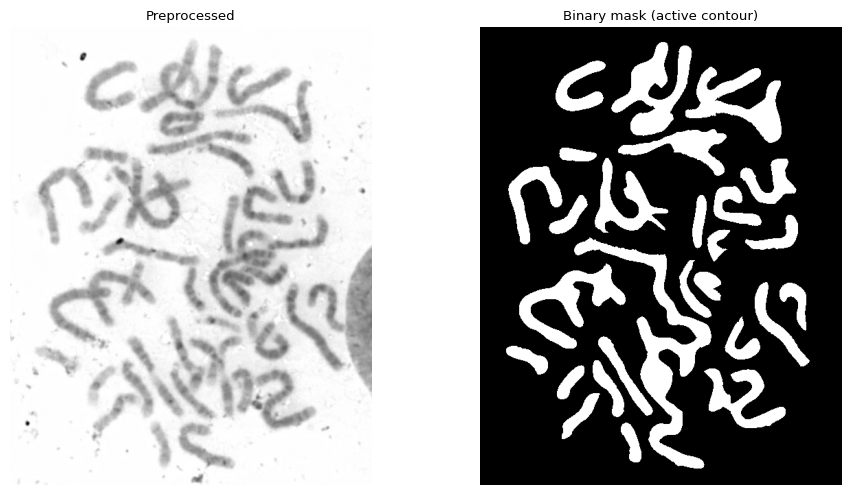

In [480]:
mask = chromosome_mask_with_active_contour(img_24[0])

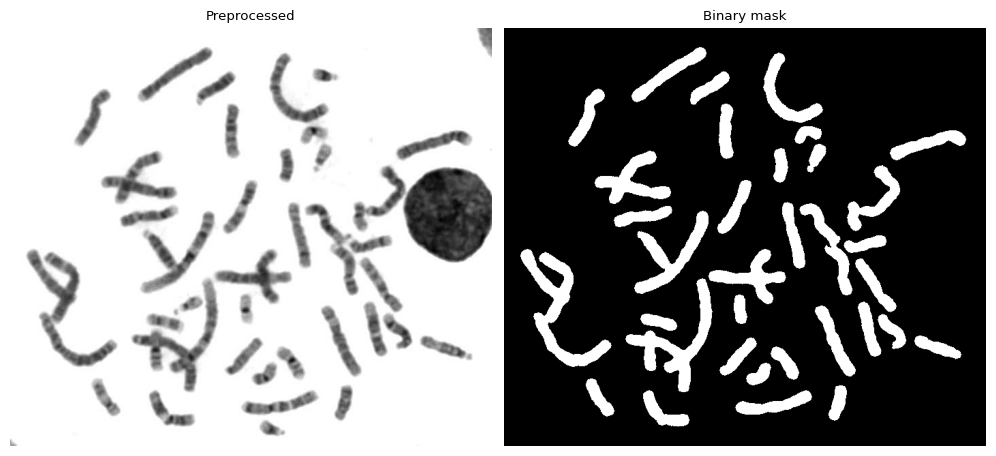

In [335]:
mask = chromosome_mask_with_contrast_stretching(img_24[2],gaussian_sigma=0.3,tophat_disk_size=15,block_size=101,opening_disk_size=5,min_object_size=600,)

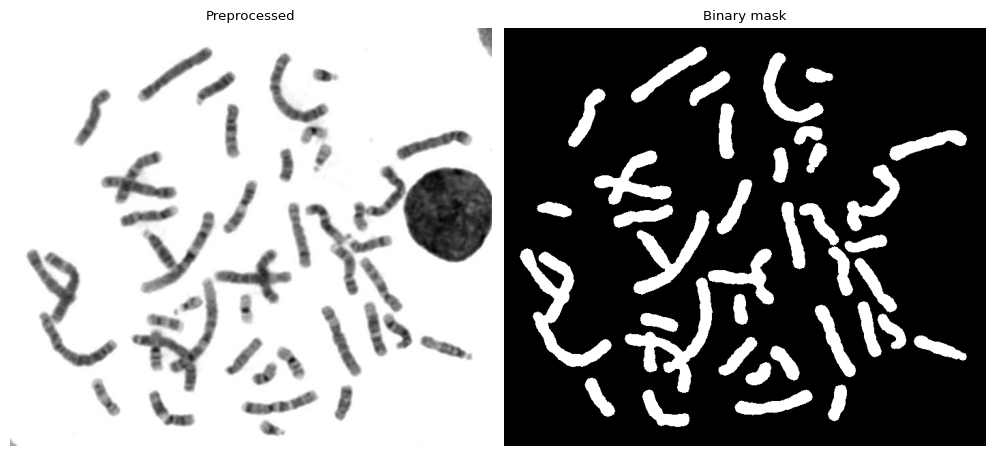

In [338]:
mask = chromosome_mask_with_adaptive_histogram(img_24[2],gaussian_sigma=0.3,tophat_disk_size=15,block_size=101,opening_disk_size=5,min_object_size=600,)

In [ ]:
# def assess_image_quality(img_path, 
#                          low_dr_threshold=0.3, 
#                          high_dr_threshold=0.7,
#                          plot=True):
#     """
#     Assess image quality and recommend preprocessing strategy.

#     Parameters
#     ----------
#     img_path         : str, Path, or array
#     low_dr_threshold : float — dynamic range below this = poor contrast
#     high_dr_threshold: float — dynamic range above this = well exposed
#     plot             : bool  — show image + histogram

#     Returns
#     -------
#     dict with metrics and recommended segment function + kwargs
#     """

#     if isinstance(img_path, (str, Path)):
#         img_raw = skimage.io.imread(img_path, as_gray=True)
#     else:
#         img_raw = img_path.copy()

#     img = np.clip(img_raw.astype(float) / img_raw.max(), 0, 1)

#     dynamic_range = img.max() - img.min()
#     std           = img.std()
#     mean          = img.mean()
#     p2, p98       = np.percentile(img, [2, 98])
#     snr           = mean / (std + 1e-8)


#     if dynamic_range < low_dr_threshold:
#         strategy    = "CLAHE"
#         reason      = f"Low dynamic range ({dynamic_range:.2f}) — needs contrast enhancement"
#         fn          = chromosome_mask_with_adaptive_histogram
#         fn_kwargs   = dict(gaussian_sigma=0.3, clahe_clip_limit=0.03)
#         color       = "tomato"

#     elif dynamic_range > high_dr_threshold:
#         strategy    = "Rescale intensity"
#         reason      = f"High dynamic range ({dynamic_range:.2f}) — rescaling is sufficient"
#         fn          = chromosome_mask_with_contrast_stretching
#         fn_kwargs   = dict(gaussian_sigma=0.77)
#         color       = "seagreen"

#     else:
#         strategy    = "CLAHE (mild)"
#         reason      = f"Moderate dynamic range ({dynamic_range:.2f}) — light enhancement"
#         fn          = chromosome_mask_with_contrast_stretching
#         fn_kwargs   = dict(gaussian_sigma=0.3, clahe_clip_limit=0.01)
#         color       = "steelblue"

#     result = {
#         "dynamic_range" : dynamic_range,
#         "std"           : std,
#         "mean"          : mean,
#         "p2_p98_range"  : p98 - p2,
#         "snr"           : snr,
#         "strategy"      : strategy,
#         "reason"        : reason,
#         "segment_fn"    : fn,
#         "segment_kwargs": fn_kwargs,
#     }

#     if plot:
#         fig, axes = plt.subplots(1, 2, figsize=(10, 4),
#                                  gridspec_kw={"width_ratios": [1, 1]})

#         axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
#         axes[0].set_title(Path(img_path).stem if isinstance(img_path, (str, Path)) else "image",
#                           fontsize=9)
#         axes[0].axis("off")

#         axes[1].hist(img.ravel(), bins=128, color=color, density=True)
#         axes[1].axvline(img.min(), color="gray",   linestyle="--", linewidth=1, label=f"min={img.min():.2f}")
#         axes[1].axvline(img.max(), color="black",  linestyle="--", linewidth=1, label=f"max={img.max():.2f}")
#         axes[1].axvline(mean,      color="orange", linestyle="-",  linewidth=1, label=f"mean={mean:.2f}")
#         axes[1].set_xlim(0, 1)
#         axes[1].set_xlabel("Intensity", fontsize=8)
#         axes[1].set_yticks([])
#         axes[1].legend(fontsize=7)
#         axes[1].set_title(f"Strategy: {strategy}\ndr={dynamic_range:.2f}  std={std:.2f}  snr={snr:.1f}",
#                           fontsize=8)

#         fig.suptitle(reason, fontsize=10, color=color)
#         plt.tight_layout()
#         plt.show()

#     return result

In [ ]:
# def batch_assess_quality(img_paths, 
#                          low_dr_threshold=0.3,
#                          high_dr_threshold=0.7,
#                          n_cols=6,
#                          figsize=(18, 10)):
#     """
#     Run assess_image_quality over all images and show a summary grid.

#     Parameters
#     ----------
#     img_paths         : list — list of file paths or arrays
#     low_dr_threshold  : float — dynamic range below this = poor contrast
#     high_dr_threshold : float — dynamic range above this = well exposed
#     n_cols            : int   — columns in the summary grid
#     figsize           : tuple — figure size

#     Returns
#     -------
#     results_df : pd.DataFrame — quality metrics + strategy for every image
#     """

#     records = []
#     for path in img_paths:
#         r = assess_image_quality(path,
#                                  low_dr_threshold=low_dr_threshold,
#                                  high_dr_threshold=high_dr_threshold,
#                                  plot=False)
#         r["path"] = path
#         r["stem"] = Path(path).stem if isinstance(path, (str, Path)) else str(path)
#         records.append(r)

#     results_df = pd.DataFrame(records).drop(columns=["segment_fn", "segment_kwargs"])

#     palette = {
#         "CLAHE"          : "tomato",
#         "CLAHE (mild)"   : "steelblue",
#         "Rescale intensity": "seagreen",
#     }


#     n         = len(img_paths)
#     n_rows    = int(np.ceil(n / n_cols))
#     fig, axes = plt.subplots(n_rows * 2, n_cols,
#                              figsize=(figsize[0], figsize[1] * n_rows / 3))

#     for i, (path, r) in enumerate(zip(img_paths, records)):
#         col   = i % n_cols
#         row   = (i // n_cols) * 2        
#         color = palette[r["strategy"]]

#         if isinstance(path, (str, Path)):
#             img = np.clip(skimage.io.imread(path, as_gray=True).astype(float), 0, 1)
#         else:
#             img = np.clip(path.astype(float) / path.max(), 0, 1)

#         axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=1)
#         axes[row, col].set_title(f"{r['stem']}\n{r['strategy']}",
#                                   fontsize=6, color=color)
#         axes[row, col].axis("off")

#         axes[row + 1, col].hist(img.ravel(), bins=64, color=color,
#                                 density=True, linewidth=0)
#         axes[row + 1, col].set_xlim(0, 1)
#         axes[row + 1, col].set_yticks([])
#         axes[row + 1, col].set_xlabel(
#             f"dr={r['dynamic_range']:.2f}  std={r['std']:.2f}", fontsize=6)


#     total_slots = n_rows * 2 * n_cols
#     for j in range(i + 1, n_rows * n_cols):
#         col = j % n_cols
#         row = (j // n_cols) * 2
#         axes[row,     col].axis("off")
#         axes[row + 1, col].axis("off")

 
#     handles = [mpatches.Patch(color=c, label=s) for s, c in palette.items()]
#     fig.legend(handles=handles, loc="lower center", ncol=3,
#                fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))

#     plt.suptitle("Batch quality assessment — recommended strategy per image",
#                  fontsize=13)
#     plt.tight_layout()
#     plt.show()


#     print("\nStrategy breakdown:")
#     print(results_df["strategy"].value_counts().to_string())
#     print(f"\nDynamic range — min: {results_df['dynamic_range'].min():.2f}  "
#           f"max: {results_df['dynamic_range'].max():.2f}  "
#           f"mean: {results_df['dynamic_range'].mean():.2f}")

#     return results_df, records

In [294]:
gray_images = [skimage.io.imread(p, as_gray=True) for p in img_24]

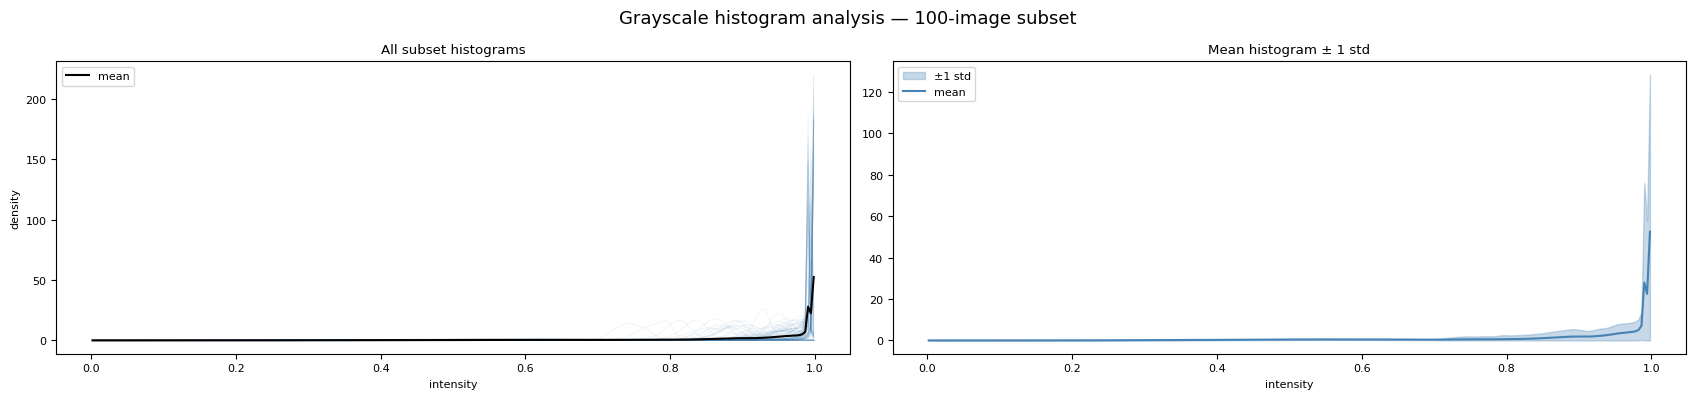

In [ ]:
BINS = 256
bin_edges = np.linspace(0, 1, BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2


all_hists = np.stack([
    np.histogram(g.ravel(), bins=bin_edges, density=True)[0]
    for g in gray_images
])

mean_hist = all_hists.mean(axis=0)
std_hist  = all_hists.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(17, 4))

for h in all_hists:
    axes[0].plot(bin_centres, h, color="steelblue", alpha=0.08, linewidth=0.7)
axes[0].plot(bin_centres, mean_hist, color="black", linewidth=1.5, label="mean")
axes[0].set_title("All subset histograms")
axes[0].set_xlabel("intensity")
axes[0].set_ylabel("density")
axes[0].legend()


axes[1].fill_between(bin_centres,
                     np.maximum(mean_hist - std_hist, 0),
                     mean_hist + std_hist,
                     alpha=0.3, color="steelblue", label="±1 std")
axes[1].plot(bin_centres, mean_hist, color="steelblue", linewidth=1.5, label="mean")
axes[1].set_title("Mean histogram ± 1 std")
axes[1].set_xlabel("intensity")
axes[1].legend()



plt.suptitle("Grayscale histogram analysis — 100-image subset", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def plot_segmentation_grid(img_paths, segment_fn, n_cols=6, figsize=(18, 10), **kwargs):
    """
    Plot a 3-row diagnostic grid for a list of images using a segmentation function.

    Rows: Preprocessed | Binary mask | Overlay

    Parameters
    ----------
    img_paths    : list — list of file paths or arrays
    segment_fn   : callable — your segment_chromosomes or segment_chromosomes_v2
    n_cols       : int — how many images to show (default 6)
    figsize      : tuple — figure size
    **kwargs     : extra args passed to segment_fn (e.g. gaussian_sigma=0.5)
    """

    row_labels = ["Preprocessed", "Binary mask", "Overlay"]
    img_paths  = img_paths[:n_cols]

    fig, axes = plt.subplots(3, len(img_paths), figsize=figsize)

    for col, img_path in enumerate(img_paths):

        if isinstance(img_path, (str, Path)):
            img_raw = skimage.io.imread(img_path, as_gray=True)
        else:
            img_raw = img_path.copy()

        img = np.clip(skimage.filters.gaussian(img_raw, kwargs.get('gaussian_sigma', 0.3),
                                               preserve_range=True), 0, 1)

        mask = segment_fn(img_path, plot=False, **kwargs)

        overlay = np.stack([img, img, img], axis=-1)
        overlay[mask] = np.clip(overlay[mask] + [0.4, -0.1, -0.1], 0, 1)

        for row, (im, cmap) in enumerate([
            (img,     "gray"),
            (mask,    "gray"),
            (overlay, None),
        ]):
            ax = axes[row, col]
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
            ax.axis("off")

            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=9)
            if row == 0:
                title = Path(img_path).stem if isinstance(img_path, (str, Path)) else f"img_{col}"
                ax.set_title(title, fontsize=8)

    plt.suptitle("Chromosome segmentation pipeline", fontsize=13)
    plt.tight_layout()
    plt.show()

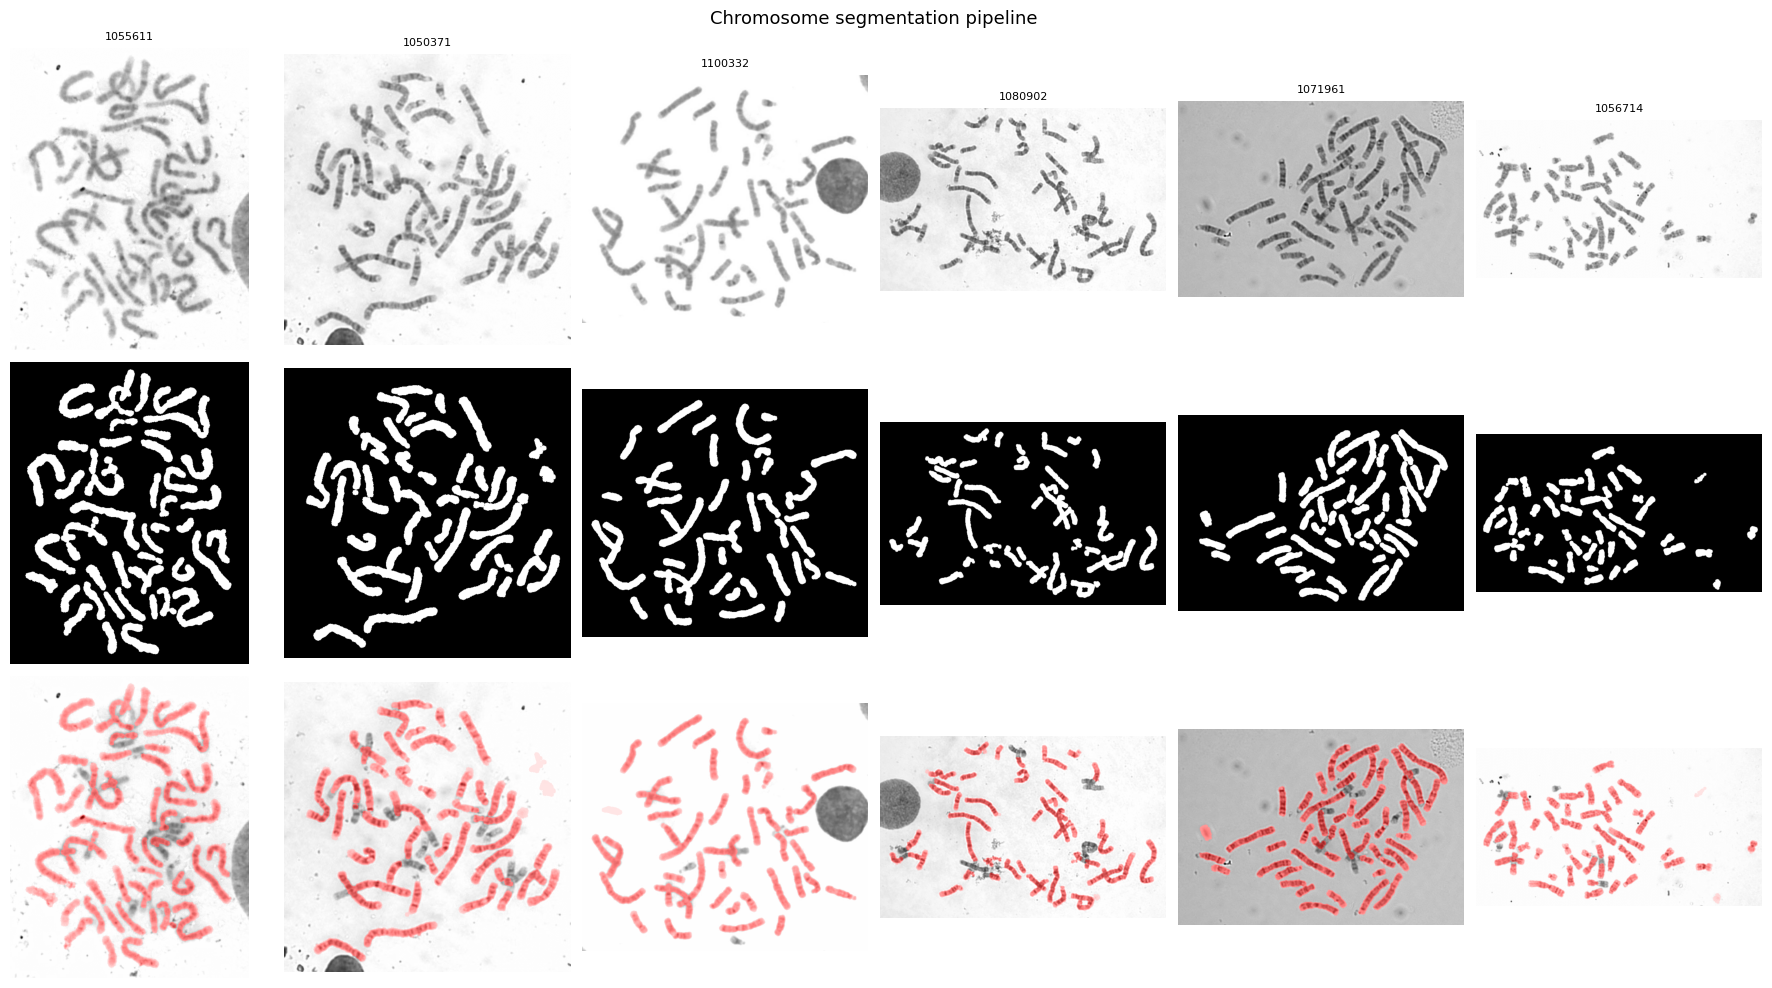

In [304]:
plot_segmentation_grid(img_24[:6], chromosome_mask_with_adaptive_histogram)

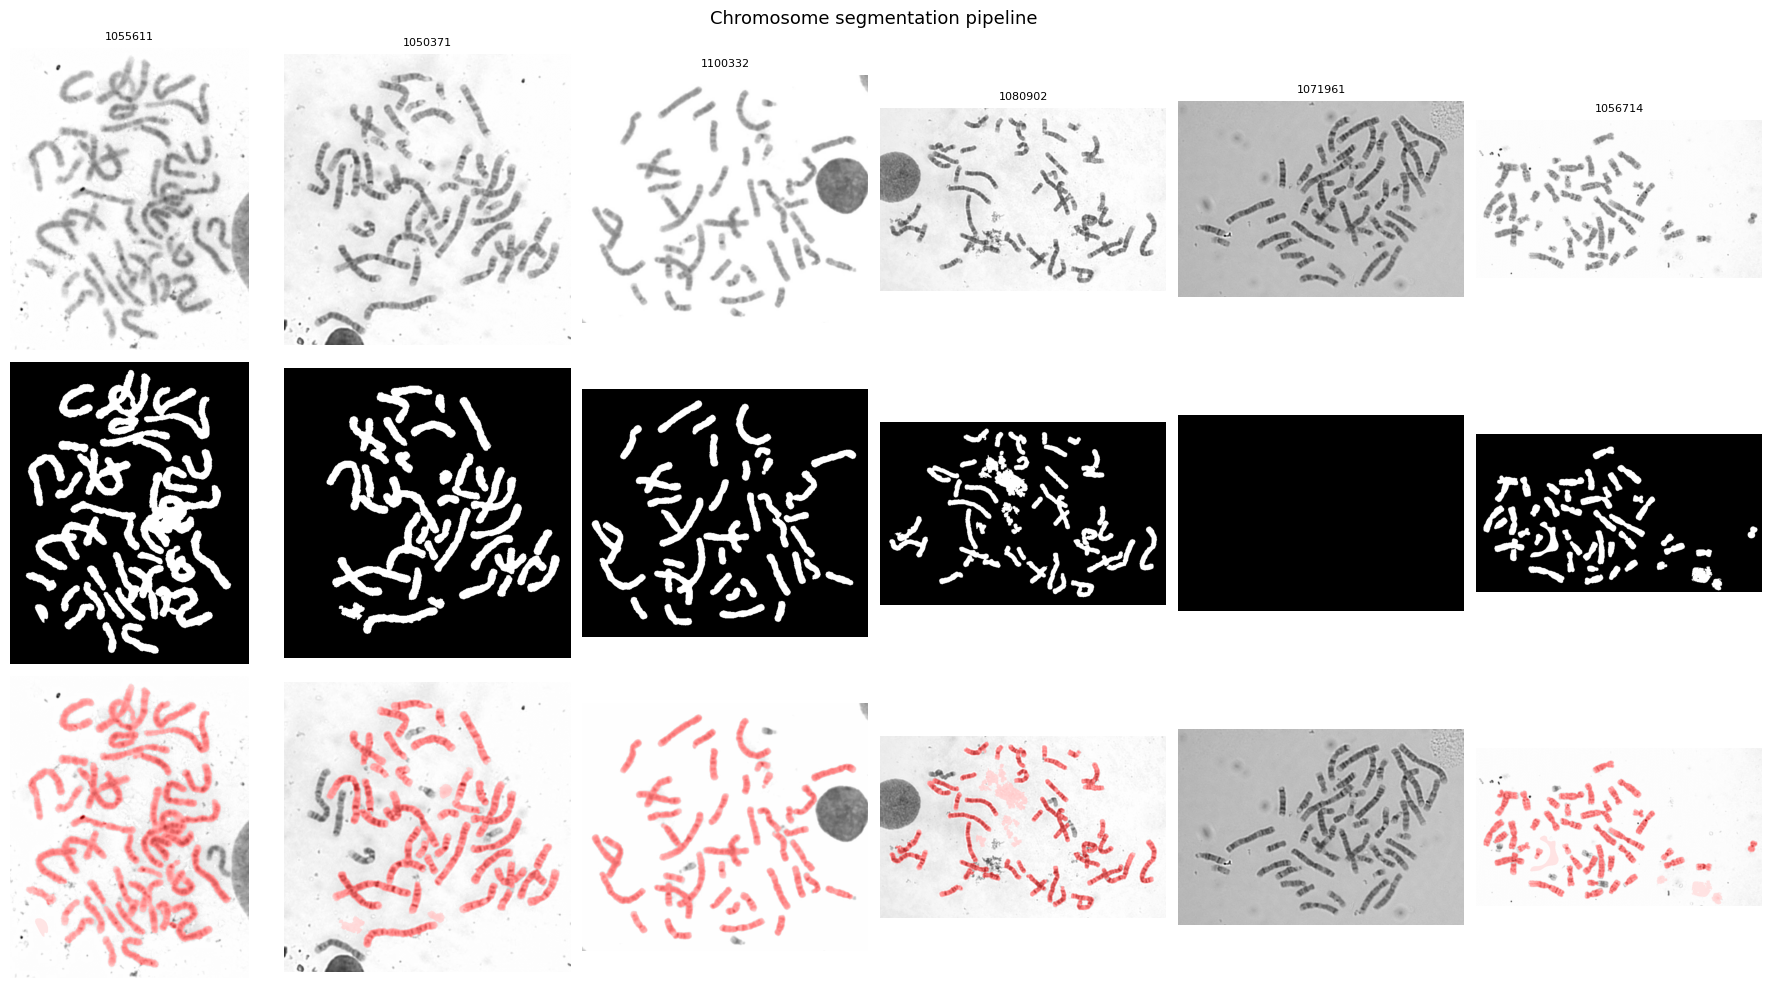

In [339]:
plot_segmentation_grid(img_24[:6], chromosome_mask_with_contrast_stretching)

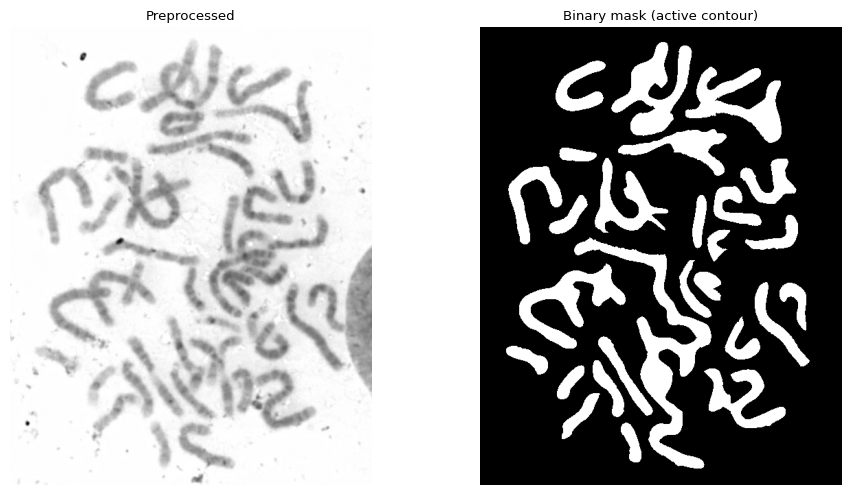

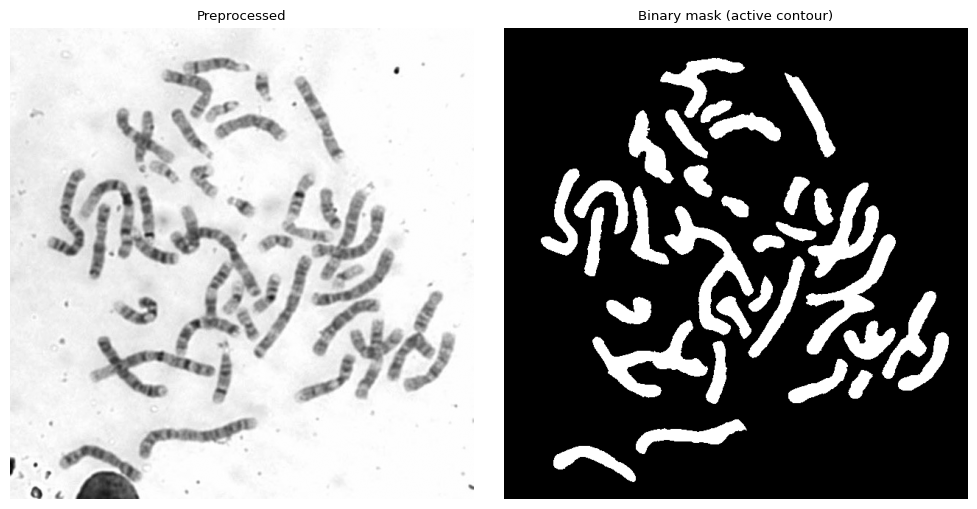

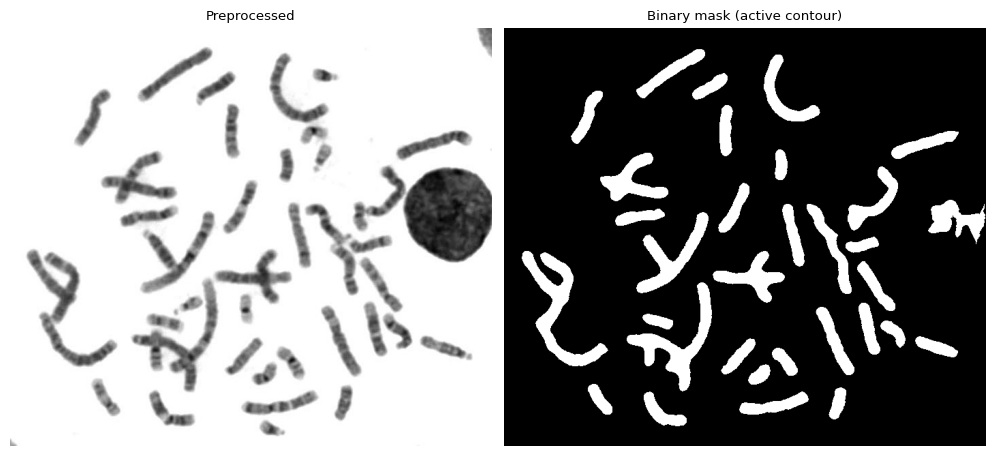

In [481]:
imgs_with_masks = []
for img_pth in img_24[:3]:
    img = skimage.io.imread(img_pth,as_gray=True)
    mask = chromosome_mask_with_active_contour(img)
    imgs_with_masks.append((img,mask))

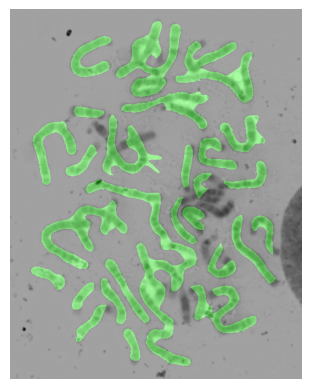

In [482]:
import numpy as np
import matplotlib.pyplot as plt

img, mask = imgs_with_masks[0]

color = (0.067, 0.988, 0)  # your RGB color

colored_mask = np.zeros((*mask.shape, 3))
colored_mask[mask > 0] = color

plt.imshow(img, cmap='gray',alpha=1)
plt.imshow(colored_mask, alpha=0.366)

plt.axis('off')
plt.show()

In [485]:
from skimage.measure import label, regionprops

labels = label(mask)
regions = regionprops(labels)

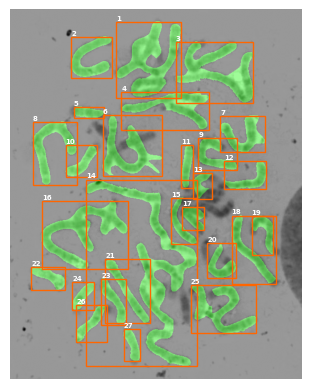

In [486]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

img, mask = imgs_with_masks[0]

color = (0.067, 0.988, 0)

# create colored mask
colored_mask = np.zeros((*mask.shape, 3))
colored_mask[mask > 0] = color

fig, ax = plt.subplots()

# show original image
ax.imshow(img, cmap='gray')

# overlay colored mask
ax.imshow(colored_mask, alpha=0.4)

for i, region in enumerate(regions):

    minr, minc, maxr, maxc = region.bbox

    rect = Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        fill=False,
        edgecolor=(255/255, 102/255, 0/255),
        linewidth=1
    )

    ax.add_patch(rect)

    # add chromosome label
    ax.text(
        minc,
        minr - 3,
        str(i+1),
        color=(255/255, 255/255, 255/255),
        fontsize=5,
        weight='bold'
    )

ax.axis('off')
plt.show()

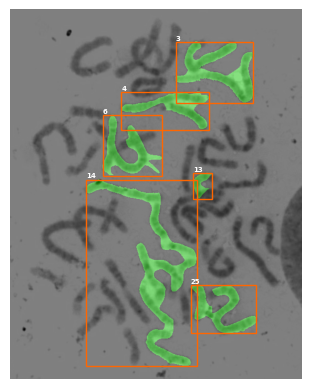

In [489]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

img, mask = imgs_with_masks[0]

selected = [14,3,25,4,13,6]
color = (13/255, 194/255, 0)

labels = label(mask)

# create colored overlay
colored_mask = np.zeros((*mask.shape,3))

for label_id in selected:
    colored_mask[labels == label_id] = color

fig, ax = plt.subplots()

ax.imshow(img, cmap='gray')
ax.imshow(colored_mask, alpha=0.5)

# draw bounding boxes
for i, region in enumerate(regions):

    if (i+1) not in selected:
        continue

    minr, minc, maxr, maxc = region.bbox

    rect = Rectangle(
        (minc, minr),
        maxc-minc,
        maxr-minr,
        fill=False,
        edgecolor=(255/255, 102/255, 0/255),
        linewidth=1
    )

    ax.text(
        minc,
        minr - 3,
        str(i+1),
        color=(255/255, 255/255, 255/255),
        fontsize=5,
        weight='bold'
    )

    ax.add_patch(rect)

ax.axis('off')
plt.show()

# HOG To be looked into Detail Later

In [ ]:
from skimage.measure import label
labels = label(mask)


In [387]:
img = skimage.io.imread(img_24[2],as_gray=True)

In [388]:
from skimage.measure import regionprops

regions = regionprops(labels)

chromosomes = []

for region in regions:
    minr, minc, maxr, maxc = region.bbox
    chrom = img[minr:maxr, minc:maxc]
    chromosomes.append((chrom,region))

In [390]:
chrom,region = chromosomes[1]

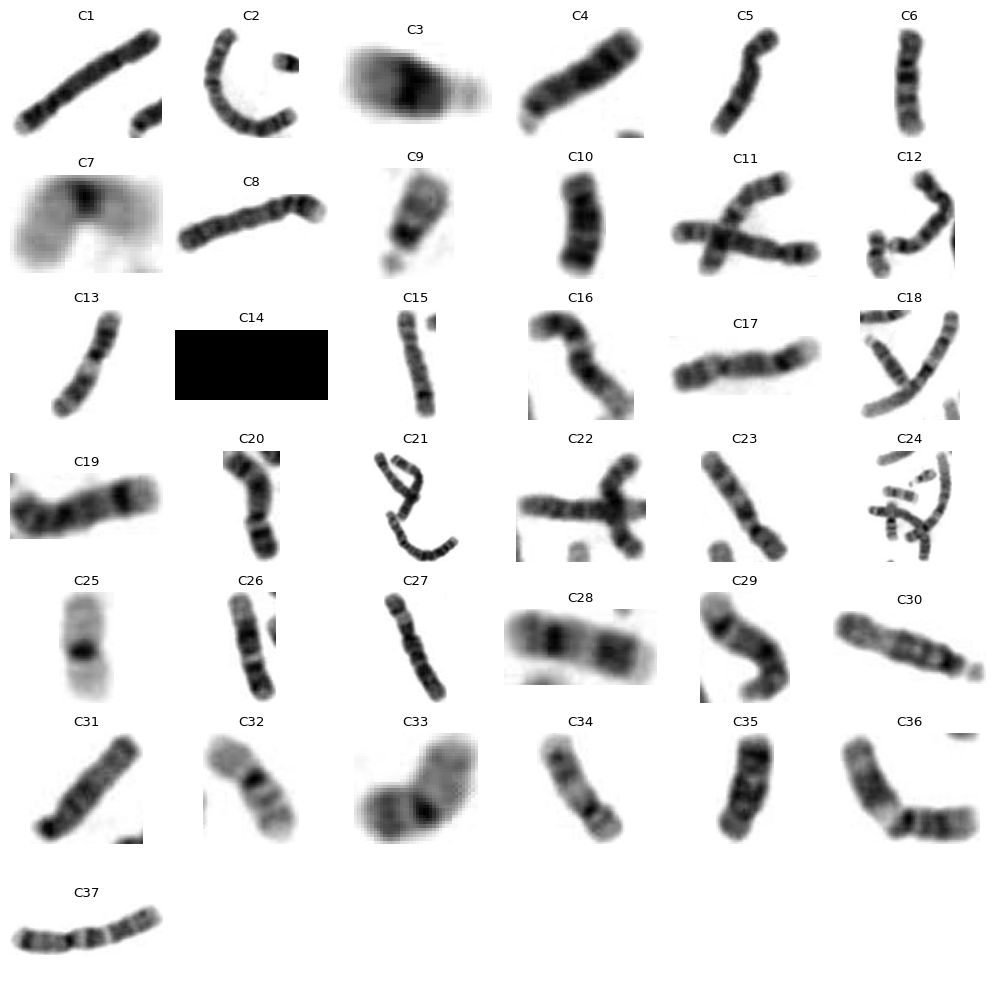

In [391]:
import matplotlib.pyplot as plt
import math

n = len(chromosomes)

cols = 6
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10,10))

for i, ax in enumerate(axes.flat):

    if i < n:
        chrom, region = chromosomes[i]
        ax.imshow(chrom, cmap='gray')
        ax.set_title(f"C{i+1}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [392]:
from skimage.transform import rotate
import numpy as np

aligned = []

for chrom, region in chromosomes:

    angle = -region.orientation * 180 / np.pi

    rotated = rotate(chrom, angle, resize=True)

    aligned.append(rotated)

In [393]:
from skimage.transform import resize

resized = []

for chrom in aligned:

    r = resize(chrom, (128, 64))

    resized.append(r)

In [394]:
from skimage.feature import hog

hog_features = []

for chrom in resized:

    features = hog(
        chrom,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2'
    )

    hog_features.append(features)

Text(0.5, 1.0, 'HOG visualization')

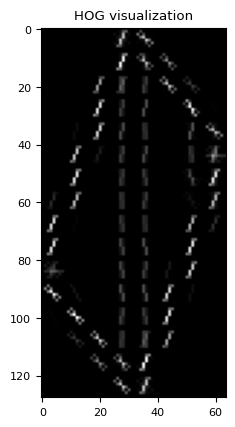

In [395]:
features, hog_image = hog(
    resized[0],
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.imshow(hog_image, cmap='gray')
plt.title("HOG visualization")